In [7]:
import numpy as np
import pandas as pd
from statistics import NormalDist
from math import log, sqrt, exp
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [ ]:

price_data = pd.concat([pd.read_csv('prices_round_3_day_0.csv',delimiter=';'), pd.read_csv('prices_round_3_day_1.csv',delimiter=';'), pd.read_csv('prices_round_3_day_2.csv',delimiter=';')])
price_data = price_data.reset_index(drop=True)

price_data['timestamp'] = price_data['timestamp']

rock_data = price_data[price_data['product'] == 'VOLCANIC_ROCK']
voucher_9500 = price_data[price_data['product'] == 'VOLCANIC_ROCK_VOUCHER_9500']
voucher_9750 = price_data[price_data['product'] == 'VOLCANIC_ROCK_VOUCHER_9750']
voucher_10000 = price_data[price_data['product'] == 'VOLCANIC_ROCK_VOUCHER_10000']
voucher_10250 = price_data[price_data['product'] == 'VOLCANIC_ROCK_VOUCHER_10250']
voucher_10500 = price_data[price_data['product'] == 'VOLCANIC_ROCK_VOUCHER_10500']

voucher_9500 = voucher_9750.reset_index(drop=True)
voucher_9750 = voucher_9750.reset_index(drop=True)
voucher_10000 = voucher_9750.reset_index(drop=True)
voucher_10250 = voucher_9750.reset_index(drop=True)
voucher_10500 = voucher_9750.reset_index(drop=True)

voucher_10250.head()

30000

In [3]:
def black_scholes_call(spot, strike, time_to_expiry, volatility):
        d1 = (
            log(spot) - log(strike) + (0.5 * volatility * volatility) * time_to_expiry
        ) / (volatility * sqrt(time_to_expiry))
        d2 = d1 - volatility * sqrt(time_to_expiry)
        call_price = spot * NormalDist().cdf(d1) - strike * NormalDist().cdf(d2)
        return call_price


def implied_volatility(
        call_price, spot, strike, time_to_expiry, max_iterations=200, tolerance=1e-10
    ):
        low_vol = 0.01
        high_vol = 1.0
        volatility = (low_vol + high_vol) / 2.0  # Initial guess as the midpoint
        for _ in range(max_iterations):
            estimated_price = black_scholes_call(
                spot, strike, time_to_expiry, volatility
            )
            diff = estimated_price - call_price
            if abs(diff) < tolerance:
                break
            elif diff > 0:
                high_vol = volatility
            else:
                low_vol = volatility
            volatility = (low_vol + high_vol) / 2.0
        return volatility

def mt(strike, voucher_price, time_to_expiry):
    return log(strike/voucher_price)/sqrt(time_to_expiry)

In [ ]:
#St - rock price at t, K - strike, Vt - option price at t, TTE - time to expiry

v_t = []
m_t = []

TTE_array = np.linspace(4,3, len(voucher_9750)+1)#*10**6

Ks = {9500: voucher_9500, 
      9750: voucher_9750, 
      10000: voucher_10000, 
      10250: voucher_10250,
      10500: voucher_10500}

def get_mt_vt(step):
      for K in Ks:
            TTE = TTE_array[step]
            St = rock_data.iloc[step]['mid_price']
            Vt = Ks[K].iloc[step]['mid_price']

            m_t.append(mt(K, St, TTE))
            v_t.append(implied_volatility(Vt, St, K, TTE))

      return m_t, v_t


[0.23549002 1.76476248 0.09402257]


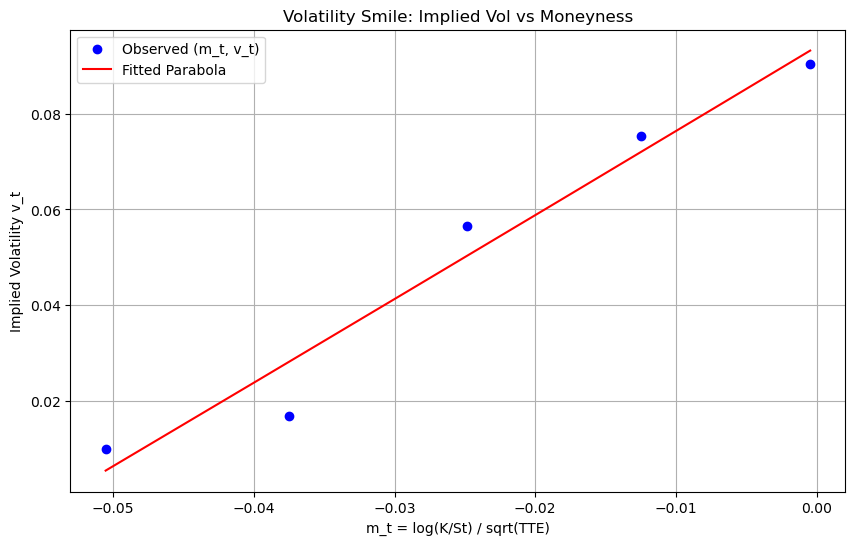

In [ ]:
parab_coeffs = []

def parabola(m, a, b, c):
    return a * m**2 + b * m + c

for i in range(30000): #10000 datapoints in a day, 3 days
    m_t, v_t = get_mt_vt(i)
    coeffs, _ = curve_fit(parabola, m_t, v_t)
    parab_coeffs.append(coeffs)



m_t_fit = np.linspace(min(m_t), max(m_t), 200)
v_t_fit = parabola(m_t_fit, *coeffs)

plt.figure(figsize=(10, 6))
plt.scatter(m_t, v_t, label="Observed (m_t, v_t)", color='blue')
plt.plot(m_t_fit, v_t_fit, label="Fitted Parabola", color='red')
plt.xlabel("m_t = log(K/St) / sqrt(TTE)")
plt.ylabel("Implied Volatility v_t")
plt.title("Volatility Smile: Implied Vol vs Moneyness")
plt.legend()
plt.grid(True)
plt.show()